# **Práctica 3 - A\*, Hill Climbing y Optimización de Redes**

---
# **1. Hill Climbing - Problema del agente viajero**

## **Actividades**

**1. Implemente distancia_tour(tour). Debe devolver la distancia total o indicar que el tour no es válido. Verifique el tour inicial 1-2-3-4-5-6-7-1.**

In [7]:
# Entradas: carreteras existentes (ciudad, ciudad, distancia), en doble sentido
CARRETERAS = [
    (1, 2, 12), (1, 3, 10), (1, 7, 12),
    (2, 3, 8), (2, 4, 12),
    (3, 4, 11), (3, 5, 3), (3, 7, 9),
    (4, 5, 11), (4, 6, 10),
    (5, 6, 6), (5, 7, 7),
    (6, 7, 9),
]

distancias = {}
for a, b, d in CARRETERAS:
    distancias.setdefault(a, {})[b] = d
    distancias.setdefault(b, {})[a] = d

In [8]:
def distancia_tour(tour, distancias):
    """Devuelve la distancia total del tour o None si usa una carretera inexistente."""
    total = 0
    for origen, destino in zip(tour, tour[1:]):
        if destino not in distancias[origen]:
            return None
        total += distancias[origen][destino]
    return total

In [9]:
TOUR_INICIAL = [1, 2, 3, 4, 5, 6, 7, 1]

for origen, destino in zip(TOUR_INICIAL, TOUR_INICIAL[1:]):
    print(f"{origen} -> {destino}: {distancias[origen].get(destino, 'no existe')}")

distancia_inicial = distancia_tour(TOUR_INICIAL, distancias)
if distancia_inicial is None:
    print("El tour inicial no es válido")
else:
    print(f"Distancia total del tour inicial: {distancia_inicial}")

1 -> 2: 12
2 -> 3: 8
3 -> 4: 11
4 -> 5: 11
5 -> 6: 6
6 -> 7: 9
7 -> 1: 12
Distancia total del tour inicial: 69


**2. Implemente vecinos(tour), generando tours mediante inversión de un sub-recorrido. La ciudad 1 debe permanecer fija.**

In [10]:
def vecinos(tour, distancias):
    """Devuelve los vecinos válidos del tour como (vecino, distancia, tramo invertido)."""
    resultado = []
    n = len(tour) - 1
    for i in range(1, n - 1):
        for j in range(i + 1, n):
            vecino = tour[:i] + tour[i:j + 1][::-1] + tour[j + 1:]
            distancia = distancia_tour(vecino, distancias)
            if distancia is not None:
                resultado.append((vecino, distancia, tour[i:j + 1]))
    return resultado

In [11]:
vecinos_iniciales = vecinos(TOUR_INICIAL, distancias)
ciudades_libres = len(TOUR_INICIAL) - 2
inversiones_posibles = ciudades_libres * (ciudades_libres - 1) // 2

print(f"Tour actual: {'-'.join(map(str, TOUR_INICIAL))} (distancia {distancia_tour(TOUR_INICIAL, distancias)})")
print(f"Vecinos válidos: {len(vecinos_iniciales)} de {inversiones_posibles} inversiones posibles")
for vecino, distancia, tramo in vecinos_iniciales:
    print(f"Invertir {tramo} -> {'-'.join(map(str, vecino))} (distancia {distancia})")

Tour actual: 1-2-3-4-5-6-7-1 (distancia 69)
Vecinos válidos: 5 de 15 inversiones posibles
Invertir [2, 3] -> 1-3-2-4-5-6-7-1 (distancia 68)
Invertir [2, 3, 4, 5, 6, 7] -> 1-7-6-5-4-3-2-1 (distancia 69)
Invertir [3, 4] -> 1-2-4-3-5-6-7-1 (distancia 65)
Invertir [4, 5] -> 1-2-3-5-4-6-7-1 (distancia 65)
Invertir [5, 6] -> 1-2-3-4-6-5-7-1 (distancia 66)


**3. Implemente Hill Climbing de máximo descenso: evalúe todos los vecinos válidos y muévase al de menor distancia. Deténgase cuando ninguno mejore el tour actual.**

In [12]:
def hill_climbing(tour_inicial, distancias):
    """Hill Climbing de máximo descenso; devuelve el tour final, su distancia y el registro por iteración."""
    tour_actual = tour_inicial
    distancia_actual = distancia_tour(tour_actual, distancias)
    registro = []
    iteracion = 0
    while True:
        iteracion += 1
        candidatos = vecinos(tour_actual, distancias)
        if not candidatos:
            break
        mejor_vecino, distancia_vecino, tramo = min(candidatos, key=lambda c: c[1])
        registro.append({
            "iteracion": iteracion,
            "tour_actual": tour_actual,
            "distancia_actual": distancia_actual,
            "mejor_vecino": mejor_vecino,
            "distancia_vecino": distancia_vecino,
            "tramo_invertido": tramo,
        })
        if distancia_vecino >= distancia_actual:
            break
        tour_actual, distancia_actual = mejor_vecino, distancia_vecino
    return tour_actual, distancia_actual, registro

In [13]:
tour_final, distancia_final, registro_hc = hill_climbing(TOUR_INICIAL, distancias)

print(f"Tour inicial: {'-'.join(map(str, TOUR_INICIAL))} (distancia {distancia_tour(TOUR_INICIAL, distancias)})")
print(f"Tour final: {'-'.join(map(str, tour_final))} (distancia {distancia_final})")
print(f"Iteraciones: {len(registro_hc)}")

Tour inicial: 1-2-3-4-5-6-7-1 (distancia 69)
Tour final: 1-2-4-6-5-3-7-1 (distancia 64)
Iteraciones: 3


**4. En cada iteración muestre: iteración, tour actual, distancia, mejor vecino, distancia del vecino y tramo invertido.**

In [14]:
def formato_tour(tour):
    """Convierte un tour en texto del tipo 1-2-3-1."""
    return "-".join(map(str, tour))


def mostrar_registro_hc(registro):
    """Imprime el registro de Hill Climbing como tabla por iteración."""
    encabezado = f"{'Iter':<5}{'Tour actual':<18}{'Dist':<6}{'Mejor vecino':<18}{'Dist':<6}{'Tramo invertido'}"
    print(encabezado)
    print("-" * len(encabezado))
    for fila in registro:
        print(f"{fila['iteracion']:<5}"
              f"{formato_tour(fila['tour_actual']):<18}"
              f"{fila['distancia_actual']:<6}"
              f"{formato_tour(fila['mejor_vecino']):<18}"
              f"{fila['distancia_vecino']:<6}"
              f"{formato_tour(fila['tramo_invertido'])}")

In [15]:
mostrar_registro_hc(registro_hc)

Iter Tour actual       Dist  Mejor vecino      Dist  Tramo invertido
--------------------------------------------------------------------
1    1-2-3-4-5-6-7-1   69    1-2-4-3-5-6-7-1   65    3-4
2    1-2-4-3-5-6-7-1   65    1-2-4-6-5-3-7-1   64    3-5-6
3    1-2-4-6-5-3-7-1   64    1-7-3-5-6-4-2-1   64    2-4-6-5-3-7


**5. Implemente una variante con reinicios aleatorios. Ejecute 100 reinicios con semilla fija y reporte el mejor tour encontrado y su distancia.**

In [16]:
import random
from collections import Counter

SEED = 123
REINICIOS = 100

In [17]:
def tour_aleatorio_valido(distancias, generador):
    """Genera permutaciones aleatorias de las ciudades 2 a 7 hasta obtener un tour válido."""
    ciudades = [c for c in distancias if c != 1]
    while True:
        generador.shuffle(ciudades)
        tour = [1] + ciudades + [1]
        if distancia_tour(tour, distancias) is not None:
            return tour


def hill_climbing_reinicios(distancias, reinicios, semilla):
    """Ejecuta Hill Climbing desde varios tours iniciales aleatorios y conserva el mejor."""
    generador = random.Random(semilla)
    mejor_tour, mejor_distancia = None, None
    resultados = []
    for reinicio in range(1, reinicios + 1):
        tour_inicial = tour_aleatorio_valido(distancias, generador)
        tour_final, distancia_final, _ = hill_climbing(tour_inicial, distancias)
        resultados.append((reinicio, tour_inicial, tour_final, distancia_final))
        if mejor_distancia is None or distancia_final < mejor_distancia:
            mejor_tour, mejor_distancia = tour_final, distancia_final
    return mejor_tour, mejor_distancia, resultados

In [18]:
mejor_tour_rr, mejor_distancia_rr, resultados_rr = hill_climbing_reinicios(distancias, REINICIOS, SEED)

print(f"Reinicios ejecutados: {len(resultados_rr)} (semilla {SEED})")
print(f"Mejor tour encontrado: {formato_tour(mejor_tour_rr)}")
print(f"Distancia del mejor tour: {mejor_distancia_rr}")
print("Distancia final alcanzada -> número de reinicios:")
for distancia, conteo in sorted(Counter(r[3] for r in resultados_rr).items()):
    print(f"{distancia} -> {conteo}")

Reinicios ejecutados: 100 (semilla 123)
Mejor tour encontrado: 1-2-4-6-7-5-3-1
Distancia del mejor tour: 63
Distancia final alcanzada -> número de reinicios:
63 -> 25
64 -> 26
65 -> 49


**6. Genere una gráfica del mejor recorrido encontrado y explique por qué Hill Climbing puede detenerse en una solución local.**

Hill Climbing únicamente compara el tour actual con sus vecinos y solo se mueve si alguno lo mejora, por lo que se detiene en cuanto todos los pasos a su alrededor lo dejan igual o peor. Es como subir la primera de varias montañas: al llegar a su cima el algoritmo se detiene sin explorar la más alta (en este problema, al minimizar, serían valles). Esto ocurrió desde el tour inicial, que terminó en 1-2-4-6-5-3-7-1 con una distancia de 64, ya que sus 3 vecinos válidos daban 64, 65 y 66. No obstante, el mejor recorrido, mostrado en la gráfica, es 1-2-4-6-7-5-3-1 con 63, y no está a una sola inversión del anterior, ya que la inversión más cercana requiere la carretera inexistente 5-1. Para alcanzarlo habría que aceptar primero un tour peor, algo que Hill Climbing no hace.

In [19]:
import math
import matplotlib.pyplot as plt

In [20]:
def graficar_tour(tour, distancias, titulo):
    """Dibuja todas las carreteras y resalta el tour indicado."""
    # Las ciudades se ubican en círculo siguiendo el orden del tour para que el recorrido sea el contorno
    ciudades = tour[:-1]
    posiciones = {
        c: (math.cos(math.pi / 2 - 2 * math.pi * k / len(ciudades)),
            math.sin(math.pi / 2 - 2 * math.pi * k / len(ciudades)))
        for k, c in enumerate(ciudades)
    }
    tramos_tour = {frozenset(par) for par in zip(tour, tour[1:])}

    fig, ax = plt.subplots(figsize=(7, 7))
    for a, b, d in CARRETERAS:
        (x1, y1), (x2, y2) = posiciones[a], posiciones[b]
        en_tour = frozenset((a, b)) in tramos_tour
        ax.plot([x1, x2], [y1, y2],
                color="tab:red" if en_tour else "lightgray",
                linewidth=3 if en_tour else 1, zorder=1)
        ax.text((x1 + x2) / 2, (y1 + y2) / 2, str(d), fontsize=9, ha="center", va="center",
                color="tab:red" if en_tour else "gray",
                bbox=dict(facecolor="white", edgecolor="none", pad=1), zorder=2)

    for origen, destino in zip(tour, tour[1:]):
        (x1, y1), (x2, y2) = posiciones[origen], posiciones[destino]
        ax.annotate("", xy=(x1 + 0.32 * (x2 - x1), y1 + 0.32 * (y2 - y1)),
                    xytext=(x1 + 0.2 * (x2 - x1), y1 + 0.2 * (y2 - y1)),
                    arrowprops=dict(arrowstyle="->", color="tab:red", lw=2), zorder=3)

    for c, (x, y) in posiciones.items():
        ax.scatter(x, y, s=600, color="tab:green" if c == tour[0] else "tab:blue", zorder=4)
        ax.text(x, y, str(c), color="white", fontsize=12, fontweight="bold",
                ha="center", va="center", zorder=5)

    ax.plot([], [], color="tab:red", linewidth=3, label=f"Tour {formato_tour(tour)}")
    ax.plot([], [], color="lightgray", linewidth=1, label="Carretera no utilizada")
    ax.scatter([], [], color="tab:green", label="Ciudad de inicio")
    ax.set_title(titulo)
    ax.set_xlabel("Posición ilustrativa x")
    ax.set_ylabel("Posición ilustrativa y")
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.22), ncol=2)
    plt.tight_layout()
    plt.show()

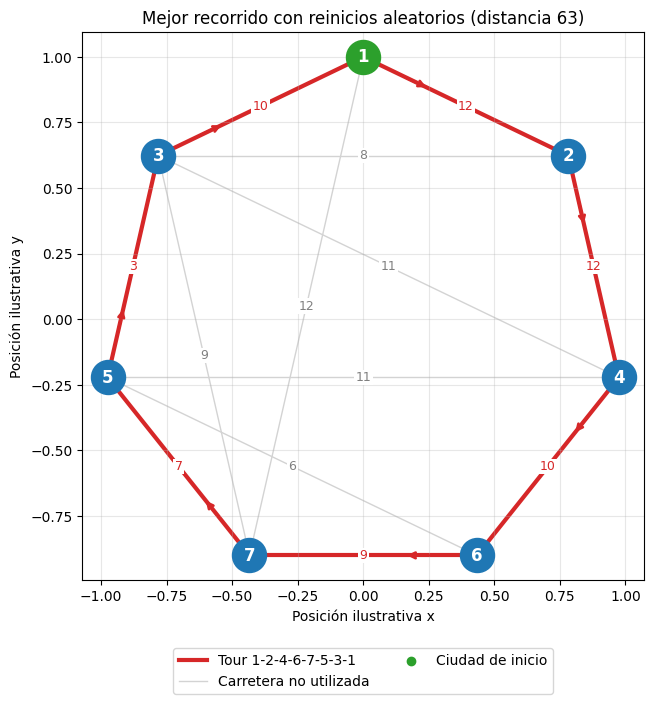

In [21]:
graficar_tour(mejor_tour_rr, distancias,
              f"Mejor recorrido con reinicios aleatorios (distancia {mejor_distancia_rr})")

## **Preguntas de análisis**

**¿Qué representa una solución, un vecino y la función objetivo en este problema?**

Una solución es un tour completo que inicia en la ciudad 1, visita las ciudades 2 a 7 exactamente una vez y regresa a la ciudad 1, como el tour inicial 1-2-3-4-5-6-7-1. Un vecino es otro tour que se obtiene al invertir un tramo del tour actual manteniendo fija la ciudad 1; por ejemplo, al invertir el tramo 3-4 del tour inicial se obtiene 1-2-4-3-5-6-7-1. De esta forma, cada tour tiene 15 vecinos posibles, aunque solo son válidos los que utilizan carreteras existentes (5 en el caso del tour inicial). Por último, la función objetivo es la distancia total del tour, la cual se busca minimizar: 69 para el tour inicial y 65 para el vecino mencionado.

**¿Por qué Hill Climbing puede detenerse aunque exista un recorrido mejor?**

Hill Climbing únicamente evalúa los vecinos del tour actual, de forma similar a un juego en el que solo se ve un radio alrededor del jugador y el resto del mapa está cubierto de niebla. Si ninguno de esos vecinos mejora la distancia, el algoritmo se detiene, aunque exista un mejor recorrido al que se podría llegar pasando antes por tours peores. Como se observó en la actividad 6, la ejecución desde el tour inicial se detuvo en un tour de 64, mientras que el mejor recorrido encontrado tiene una distancia de 63.

**¿Qué efecto tuvieron los reinicios aleatorios?**

Los reinicios aleatorios permitieron que el algoritmo partiera de 100 tours iniciales distintos con la semilla 123, por lo que, aunque cada ejecución sigue viendo únicamente a sus vecinos, en conjunto se exploraron distintas regiones de las posibles soluciones. Gracias a esto se encontró el tour 1-2-4-6-7-5-3-1 con una distancia de 63, mejor que el de 64 obtenido con una sola ejecución. No obstante, solo 25 de los 100 reinicios llegaron a 63, mientras que 26 terminaron en 64 y 49 en 65, por lo que los reinicios no garantizan el mejor resultado, sino que aumentan la probabilidad de encontrarlo a cambio de ejecutar el algoritmo más veces.

---
# **2. A\* - Ruta más corta en una red**

## **Modelado del problema**

In [22]:
# Entradas: estaciones, caminos de doble sentido (estación, estación, distancia) y coordenadas
ESTACIONES = ["O", "A", "B", "C", "D", "E", "T"]
CAMINOS = [
    ("O", "A", 2), ("O", "B", 5), ("O", "C", 4),
    ("A", "B", 2), ("A", "D", 7),
    ("B", "C", 1), ("B", "D", 4), ("B", "E", 3),
    ("C", "E", 4),
    ("D", "E", 1), ("D", "T", 5),
    ("E", "T", 7),
]
COORDENADAS = {
    "O": (0.0, 0.0), "A": (1.5, 1.2), "B": (2.5, 0.0), "C": (2.8, -0.8),
    "D": (5.5, 1.0), "E": (5.2, 0.2), "T": (9.0, 0.5),
}
INICIO, META = "O", "T"

# Matriz de adyacencia: grafo[i][j] es la distancia entre las estaciones i y j, 0 si no hay camino
indice = {estacion: i for i, estacion in enumerate(ESTACIONES)}
grafo = [[0] * len(ESTACIONES) for _ in ESTACIONES]
for a, b, d in CAMINOS:
    grafo[indice[a]][indice[b]] = d
    grafo[indice[b]][indice[a]] = d

print("   " + "".join(f"{e:>4}" for e in ESTACIONES))
for estacion, fila in zip(ESTACIONES, grafo):
    print(f"{estacion:<3}" + "".join(f"{d:>4}" for d in fila))

      O   A   B   C   D   E   T
O     0   2   5   4   0   0   0
A     2   0   2   0   7   0   0
B     5   2   0   1   4   3   0
C     4   0   1   0   0   4   0
D     0   7   4   0   0   1   5
E     0   0   3   4   1   0   7
T     0   0   0   0   5   7   0


## **Actividades**

**7. Implemente una función heuristica(nodo, meta, coordenadas) usando distancia euclidiana.**

In [35]:
def heuristica(nodo, meta, coordenadas):
    """Distancia euclidiana entre el nodo y la meta según sus coordenadas."""
    x1, y1 = coordenadas[nodo]
    x2, y2 = coordenadas[meta]
    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

In [36]:
for estacion in ESTACIONES:
    print(f"h({estacion}) = {heuristica(estacion, META, COORDENADAS):.3f}")

h(O) = 9.014
h(A) = 7.533
h(B) = 6.519
h(C) = 6.335
h(D) = 3.536
h(E) = 3.812
h(T) = 0.000


**8. Implemente A\* utilizando heapq. No utilizar networkx para resolver la búsqueda.**

In [37]:
import heapq

In [38]:
def a_estrella(grafo, coordenadas, inicio, meta, funcion_h=heuristica):
    """Búsqueda A* sobre la matriz de adyacencia; devuelve camino, costo y registro por iteración."""
    estaciones = list(coordenadas)
    indice = {estacion: i for i, estacion in enumerate(estaciones)}

    mejor_g = {inicio: 0}
    padre = {inicio: None}
    cerrados = set()
    abierta = [(funcion_h(inicio, meta, coordenadas), inicio)]
    registro = []

    while abierta:
        f, nodo = heapq.heappop(abierta)
        if nodo in cerrados:
            continue  # entrada vieja: el nodo ya se expandió con un g menor
        cerrados.add(nodo)
        g = mejor_g[nodo]
        h = funcion_h(nodo, meta, coordenadas)

        if nodo != meta:
            for vecino, distancia in zip(estaciones, grafo[indice[nodo]]):
                if distancia == 0 or vecino in cerrados:
                    continue
                g_nuevo = g + distancia
                if g_nuevo < mejor_g.get(vecino, float("inf")):
                    mejor_g[vecino] = g_nuevo
                    padre[vecino] = nodo
                    heapq.heappush(abierta, (g_nuevo + funcion_h(vecino, meta, coordenadas), vecino))

        # Lista abierta sin entradas viejas, ordenada por f
        abierta_vigente = sorted(
            (f_v, v) for f_v, v in abierta
            if v not in cerrados and f_v == mejor_g[v] + funcion_h(v, meta, coordenadas)
        )
        registro.append({"iteracion": len(registro) + 1, "nodo": nodo, "g": g, "h": h, "f": g + h,
                         "abierta": abierta_vigente})
        if nodo == meta:
            break

    if meta not in cerrados:
        return None, None, registro
    camino = [meta]
    while padre[camino[-1]] is not None:
        camino.append(padre[camino[-1]])
    return camino[::-1], mejor_g[meta], registro

**9. En cada iteración muestre: nodo expandido, g(n), h(n), f(n) y contenido de la lista abierta.**

In [39]:
def mostrar_registro_a_estrella(registro):
    """Imprime el registro de A* como tabla por iteración."""
    encabezado = f"{'Iter':<5}{'Nodo':<6}{'g(n)':<7}{'h(n)':<8}{'f(n)':<8}{'Lista abierta (nodo: f)'}"
    print(encabezado)
    print("-" * 80)
    for fila in registro:
        abierta = ", ".join(f"{v}: {f_v:.2f}" for f_v, v in fila["abierta"]) or "vacía"
        print(f"{fila['iteracion']:<5}{fila['nodo']:<6}{fila['g']:<7}{fila['h']:<8.2f}{fila['f']:<8.2f}{abierta}")

In [40]:
camino_ae, costo_ae, registro_ae = a_estrella(grafo, COORDENADAS, INICIO, META)
mostrar_registro_a_estrella(registro_ae)

Iter Nodo  g(n)   h(n)    f(n)    Lista abierta (nodo: f)
--------------------------------------------------------------------------------
1    O     0      9.01    9.01    A: 9.53, C: 10.33, B: 11.52
2    A     2      7.53    9.53    C: 10.33, B: 10.52, D: 12.54
3    C     4      6.33    10.33   B: 10.52, E: 11.81, D: 12.54
4    B     4      6.52    10.52   E: 10.81, D: 11.54
5    E     7      3.81    10.81   D: 11.54, T: 14.00
6    D     8      3.54    11.54   T: 13.00
7    T     13     0.00    13.00   vacía


**10. Encuentre la ruta de O a T, muestre el camino final y su costo total.**

In [41]:
print(f"Camino final de {INICIO} a {META}: {' -> '.join(camino_ae)}")
print(f"Costo total: {costo_ae}")
print(f"Nodos expandidos: {len(registro_ae)}")

Camino final de O a T: O -> A -> B -> D -> T
Costo total: 13
Nodos expandidos: 7


**11. Ejecute nuevamente el algoritmo utilizando h(n)=0. Compare el resultado con A\* y explique la relación con Dijkstra.**

Con h(n)=0, f(n) pasa a ser únicamente g(n), por lo que siempre se expande el nodo con menor costo acumulado desde O sin estimar cuánto falta para llegar a T, que es exactamente lo que hace Dijkstra. Ambas versiones encontraron la ruta O -> A -> B -> D -> T con costo 13 y expandieron los 7 nodos, ya que la distancia en línea recta subestima bastante los caminos reales (h(O) = 9.01 frente a 13) y ningún nodo alcanzó un f(n) mayor al costo óptimo, por lo que la heurística no logró descartar ninguno.

In [42]:
def heuristica_cero(nodo, meta, coordenadas):
    """Heurística nula: A* con esta función se comporta como Dijkstra."""
    return 0

In [43]:
camino_dij, costo_dij, registro_dij = a_estrella(grafo, COORDENADAS, INICIO, META, funcion_h=heuristica_cero)
mostrar_registro_a_estrella(registro_dij)

Iter Nodo  g(n)   h(n)    f(n)    Lista abierta (nodo: f)
--------------------------------------------------------------------------------
1    O     0      0.00    0.00    A: 2.00, C: 4.00, B: 5.00
2    A     2      0.00    2.00    B: 4.00, C: 4.00, D: 9.00
3    B     4      0.00    4.00    C: 4.00, E: 7.00, D: 8.00
4    C     4      0.00    4.00    E: 7.00, D: 8.00
5    E     7      0.00    7.00    D: 8.00, T: 14.00
6    D     8      0.00    8.00    T: 13.00
7    T     13     0.00    13.00   vacía


In [44]:
print(f"{'Versión':<12}{'Camino':<24}{'Costo':<7}{'Nodos expandidos':<18}{'Orden de expansión'}")
print("-" * 80)
for nombre, camino, costo, registro in [("A*", camino_ae, costo_ae, registro_ae),
                                        ("h(n) = 0", camino_dij, costo_dij, registro_dij)]:
    orden = ", ".join(fila["nodo"] for fila in registro)
    print(f"{nombre:<12}{' -> '.join(camino):<24}{costo:<7}{len(registro):<18}{orden}")

Versión     Camino                  Costo  Nodos expandidos  Orden de expansión
--------------------------------------------------------------------------------
A*          O -> A -> B -> D -> T   13     7                 O, A, C, B, E, D, T
h(n) = 0    O -> A -> B -> D -> T   13     7                 O, A, B, C, E, D, T


**12. Grafique la red con matplotlib y resalte la ruta encontrada.**

In [45]:
def graficar_red(caminos, coordenadas, ruta, titulo):
    """Dibuja la red con sus coordenadas y resalta la ruta indicada."""
    tramos_ruta = {frozenset(par) for par in zip(ruta, ruta[1:])}

    fig, ax = plt.subplots(figsize=(10, 5))
    for a, b, d in caminos:
        (x1, y1), (x2, y2) = coordenadas[a], coordenadas[b]
        en_ruta = frozenset((a, b)) in tramos_ruta
        ax.plot([x1, x2], [y1, y2], color="tab:red" if en_ruta else "lightgray",
                linewidth=3 if en_ruta else 1.5, zorder=1)
        ax.text((x1 + x2) / 2, (y1 + y2) / 2, str(d), fontsize=10, ha="center", va="center",
                color="tab:red" if en_ruta else "gray",
                bbox=dict(facecolor="white", edgecolor="none", pad=1), zorder=2)

    for origen, destino in zip(ruta, ruta[1:]):
        (x1, y1), (x2, y2) = coordenadas[origen], coordenadas[destino]
        ax.annotate("", xy=(x1 + 0.35 * (x2 - x1), y1 + 0.35 * (y2 - y1)),
                    xytext=(x1 + 0.2 * (x2 - x1), y1 + 0.2 * (y2 - y1)),
                    arrowprops=dict(arrowstyle="->", color="tab:red", lw=2), zorder=3)

    for estacion, (x, y) in coordenadas.items():
        color = "tab:green" if estacion == ruta[0] else "tab:orange" if estacion == ruta[-1] else "tab:blue"
        ax.scatter(x, y, s=500, color=color, zorder=4)
        ax.text(x, y, estacion, color="white", fontsize=12, fontweight="bold",
                ha="center", va="center", zorder=5)

    ax.plot([], [], color="tab:red", linewidth=3, label=f"Ruta {' -> '.join(ruta)}")
    ax.plot([], [], color="lightgray", linewidth=1.5, label="Camino no utilizado")
    ax.scatter([], [], color="tab:green", label="Inicio")
    ax.scatter([], [], color="tab:orange", label="Meta")
    ax.set_title(titulo)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(-0.6, 9.6)
    ax.set_ylim(-1.4, 1.8)
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

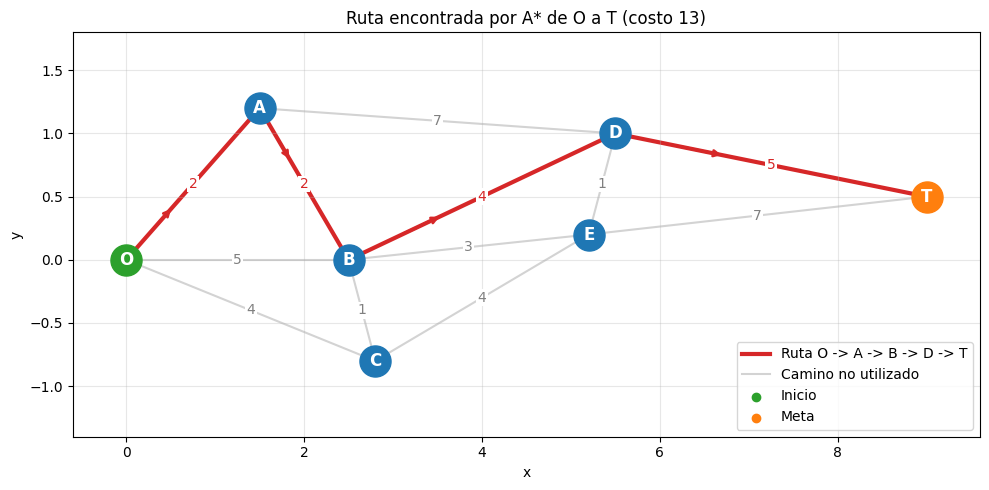

In [46]:
graficar_red(CAMINOS, COORDENADAS, camino_ae, f"Ruta encontrada por A* de {INICIO} a {META} (costo {costo_ae})")

## **Preguntas de análisis**

**¿Qué información aporta g(n)? ¿Qué información aporta h(n)?**

g(n) aporta el costo real acumulado desde el origen hasta el nodo n por el mejor camino encontrado hasta el momento; por ejemplo, al llegar a B por O -> A -> B se tiene g(B) = 2 + 2 = 4, valor que reemplazó al g(B) = 5 del camino directo O -> B. Por su parte, h(n) aporta una estimación de cuánto falta para llegar a la meta desde n, que en este caso es la distancia en línea recta hasta T, como h(B) = 6.52. De esta forma, g(n) indica qué tan caro ha sido llegar a un nodo y h(n) le da a A\* una noción de hacia dónde está la meta, de tal forma que no avance a ciegas.

**¿Por qué una heurística útil puede reducir la cantidad de nodos explorados?**

Una heurística útil funciona como una guía, ya que entre dos nodos con el mismo costo acumulado A\* expande primero el que, según h(n), está más cerca de la meta; por ejemplo, si llegar a dos vecinos cuesta lo mismo pero uno tiene h(n) = 10 y el otro h(n) = 5, se avanza por el segundo y el primero puede no llegar a expandirse nunca. Así, siempre que la heurística no sobreestime el costo real, A\* puede descartar los nodos cuyo f(n) supera el costo de la ruta óptima. No obstante, en nuestra red este ahorro no se observó, debido a que la distancia en línea recta es bastante menor que los caminos reales y ningún nodo superó el costo óptimo de 13; mientras más cercana sea h(n) al costo real, más nodos se pueden descartar.

**¿Qué ocurre conceptualmente cuando h(n)=0?**

Cuando h(n)=0 se le quita al algoritmo la noción de hacia dónde está la meta, por lo que f(n) = g(n) y A\* se convierte en Dijkstra, expandiendo los nodos en orden de su costo acumulado desde el origen y en todas las direcciones por igual. La ruta encontrada sigue siendo óptima, ya que h(n)=0 nunca sobreestima, pero se pierde la ventaja de A\*, que es explorar menos nodos al dirigir la búsqueda hacia la meta.

---
# **3. Flujo Máximo y Costo Mínimo - Distribución de suministros**

## **Modelado del problema**

In [47]:
# Entradas: tramos dirigidos (origen, destino, capacidad, costo por unidad)
TRAMOS = [
    ("S", "A", 5, 2), ("S", "B", 7, 1), ("S", "C", 4, 3),
    ("A", "B", 1, 1), ("A", "D", 3, 2),
    ("B", "C", 2, 1), ("B", "D", 4, 3), ("B", "E", 5, 2),
    ("C", "E", 4, 1),
    ("D", "T", 9, 2),
    ("E", "D", 1, 1), ("E", "T", 6, 3),
]
FUENTE, DESTINO = "S", "T"

capacidades = {(u, v): cap for u, v, cap, _ in TRAMOS}
costos = {(u, v): costo for u, v, _, costo in TRAMOS}

print(f"{'Tramo':<9}{'Capacidad':<11}{'Costo/unidad'}")
for (u, v), cap in capacidades.items():
    print(f"{u} -> {v:<4}{cap:<11}{costos[(u, v)]}")

Tramo    Capacidad  Costo/unidad
S -> A   5          2
S -> B   7          1
S -> C   4          3
A -> B   1          1
A -> D   3          2
B -> C   2          1
B -> D   4          3
B -> E   5          2
C -> E   4          1
D -> T   9          2
E -> D   1          1
E -> T   6          3


## **Parte A - Flujo Máximo**

**13. Construya la red residual incluyendo aristas de regreso con capacidad inicial 0.**

In [48]:
def construir_red_residual(capacidades):
    """Red residual como diccionario de diccionarios, con aristas de regreso en capacidad 0."""
    residual = {}
    for (u, v), cap in capacidades.items():
        residual.setdefault(u, {})[v] = cap
        residual.setdefault(v, {}).setdefault(u, 0)
    return residual

In [49]:
residual_inicial = construir_red_residual(capacidades)

print(f"{'Arista':<10}{'Tipo':<10}{'Capacidad residual'}")
for u in residual_inicial:
    for v, cap in residual_inicial[u].items():
        tipo = "original" if (u, v) in capacidades else "regreso"
        print(f"{u} -> {v:<5}{tipo:<10}{cap}")

Arista    Tipo      Capacidad residual
S -> A    original  5
S -> B    original  7
S -> C    original  4
A -> S    regreso   0
A -> B    original  1
A -> D    original  3
B -> S    regreso   0
B -> A    regreso   0
B -> C    original  2
B -> D    original  4
B -> E    original  5
C -> S    regreso   0
C -> B    regreso   0
C -> E    original  4
D -> A    regreso   0
D -> B    regreso   0
D -> T    original  9
D -> E    regreso   0
E -> B    regreso   0
E -> C    regreso   0
E -> D    original  1
E -> T    original  6
T -> D    regreso   0
T -> E    regreso   0


**14. Implemente Edmonds-Karp: utilice BFS para buscar caminos aumentantes desde S hasta T.**

In [50]:
from collections import deque

In [51]:
def bfs_camino(residual, fuente, destino):
    """Busca con BFS el camino con menos aristas de fuente a destino con capacidad residual positiva."""
    padre = {fuente: None}
    cola = deque([fuente])
    while cola:
        u = cola.popleft()
        if u == destino:
            break
        for v, cap in residual[u].items():
            if cap > 0 and v not in padre:
                padre[v] = u
                cola.append(v)
    if destino not in padre:
        return None
    camino = [destino]
    while padre[camino[-1]] is not None:
        camino.append(padre[camino[-1]])
    return camino[::-1]


def edmonds_karp(capacidades, fuente, destino):
    """Flujo máximo con Edmonds-Karp; devuelve flujo máximo, flujo por tramo, registro y red residual final."""
    residual = construir_red_residual(capacidades)
    flujo = {tramo: 0 for tramo in capacidades}
    flujo_total = 0
    registro = []

    while True:
        camino = bfs_camino(residual, fuente, destino)
        if camino is None:
            break
        tramos_camino = list(zip(camino, camino[1:]))
        cuello = min(residual[u][v] for u, v in tramos_camino)

        for u, v in tramos_camino:
            residual[u][v] -= cuello
            residual[v][u] += cuello
            if (u, v) in capacidades:
                flujo[(u, v)] += cuello
            else:
                flujo[(v, u)] -= cuello  # se usó una arista de regreso: se cancela flujo anterior
        flujo_total += cuello
        registro.append({"iteracion": len(registro) + 1, "camino": camino, "cuello": cuello,
                         "enviado": cuello, "acumulado": flujo_total})

    return flujo_total, flujo, registro, residual

**15. En cada iteración muestre: camino aumentante, cuello de botella, flujo enviado y flujo acumulado.**

In [52]:
def mostrar_registro_ek(registro):
    """Imprime el registro de Edmonds-Karp como tabla por iteración."""
    encabezado = f"{'Iter':<6}{'Camino aumentante':<24}{'Cuello de botella':<19}{'Flujo enviado':<15}{'Flujo acumulado'}"
    print(encabezado)
    print("-" * len(encabezado))
    for fila in registro:
        print(f"{fila['iteracion']:<6}{' -> '.join(fila['camino']):<24}{fila['cuello']:<19}"
              f"{fila['enviado']:<15}{fila['acumulado']}")

In [53]:
flujo_maximo, flujo_ek, registro_ek, residual_ek = edmonds_karp(capacidades, FUENTE, DESTINO)
mostrar_registro_ek(registro_ek)

Iter  Camino aumentante       Cuello de botella  Flujo enviado  Flujo acumulado
-------------------------------------------------------------------------------
1     S -> A -> D -> T        3                  3              3
2     S -> B -> D -> T        4                  4              7
3     S -> B -> E -> T        3                  3              10
4     S -> C -> E -> T        3                  3              13
5     S -> C -> E -> D -> T   1                  1              14


**16. Al finalizar, muestre el flujo máximo y el flujo utilizado en cada tramo.**

In [54]:
print(f"Flujo máximo de {FUENTE} a {DESTINO}: {flujo_maximo}\n")
print(f"{'Tramo':<9}{'Flujo':<7}{'Capacidad':<11}{'Uso'}")
for (u, v), cap in capacidades.items():
    f = flujo_ek[(u, v)]
    estado = "lleno" if f == cap else "sin usar" if f == 0 else "parcial"
    print(f"{u} -> {v:<4}{f:<7}{cap:<11}{estado}")

Flujo máximo de S a T: 14

Tramo    Flujo  Capacidad  Uso
S -> A   3      5          parcial
S -> B   7      7          lleno
S -> C   4      4          lleno
A -> B   0      1          sin usar
A -> D   3      3          lleno
B -> C   0      2          sin usar
B -> D   4      4          lleno
B -> E   3      5          parcial
C -> E   4      4          lleno
D -> T   8      9          parcial
E -> D   1      1          lleno
E -> T   6      6          lleno


**17. Verifique por código que ningún tramo exceda su capacidad y que en cada nodo intermedio el flujo que entra sea igual al flujo que sale.**

In [55]:
def verificar_flujo(flujo, capacidades, fuente, destino):
    """Verifica capacidad en cada tramo y conservación del flujo en cada nodo intermedio."""
    valido = True
    print("Capacidades:")
    for tramo, cap in capacidades.items():
        ok = 0 <= flujo[tramo] <= cap
        valido &= ok
        if not ok:
            print(f"{tramo[0]} -> {tramo[1]} excede su capacidad: {flujo[tramo]} de {cap}")
    print("Ningún tramo excede su capacidad" if valido else "Hay tramos fuera de su capacidad")

    print("\nConservación en nodos intermedios:")
    nodos = {u for u, _ in capacidades} | {v for _, v in capacidades}
    for nodo in sorted(nodos - {fuente, destino}):
        entra = sum(f for (u, v), f in flujo.items() if v == nodo)
        sale = sum(f for (u, v), f in flujo.items() if u == nodo)
        ok = entra == sale
        valido &= ok
        print(f"{nodo}: entra {entra}, sale {sale} -> {'cumple' if ok else 'no cumple'}")

    sale_fuente = sum(f for (u, v), f in flujo.items() if u == fuente)
    entra_destino = sum(f for (u, v), f in flujo.items() if v == destino)
    print(f"\nSale de {fuente}: {sale_fuente}, entra a {destino}: {entra_destino}")
    return valido

In [56]:
print(f"Flujo válido: {verificar_flujo(flujo_ek, capacidades, FUENTE, DESTINO)}")

Capacidades:
Ningún tramo excede su capacidad

Conservación en nodos intermedios:
A: entra 3, sale 3 -> cumple
B: entra 7, sale 7 -> cumple
C: entra 4, sale 4 -> cumple
D: entra 8, sale 8 -> cumple
E: entra 7, sale 7 -> cumple

Sale de S: 14, entra a T: 14
Flujo válido: True


## **Parte B - Costo Mínimo**

**18. Represente para cada arista su capacidad, costo y flujo actual.**

In [57]:
def crear_aristas(capacidades, costos):
    """Representa cada arista original con su capacidad, costo por unidad y flujo actual."""
    return {tramo: {"capacidad": capacidades[tramo], "costo": costos[tramo], "flujo": 0}
            for tramo in capacidades}


def mostrar_aristas(aristas):
    """Imprime capacidad, costo, flujo y costo total de cada arista."""
    print(f"{'Tramo':<9}{'Capacidad':<11}{'Costo/u':<9}{'Flujo':<7}{'Costo del tramo'}")
    for (u, v), datos in aristas.items():
        print(f"{u} -> {v:<4}{datos['capacidad']:<11}{datos['costo']:<9}{datos['flujo']:<7}"
              f"{datos['flujo'] * datos['costo']}")

In [58]:
aristas_iniciales = crear_aristas(capacidades, costos)
mostrar_aristas(aristas_iniciales)

Tramo    Capacidad  Costo/u  Flujo  Costo del tramo
S -> A   5          2        0      0
S -> B   7          1        0      0
S -> C   4          3        0      0
A -> B   1          1        0      0
A -> D   3          2        0      0
B -> C   2          1        0      0
B -> D   4          3        0      0
B -> E   5          2        0      0
C -> E   4          1        0      0
D -> T   9          2        0      0
E -> D   1          1        0      0
E -> T   6          3        0      0


**19. Implemente una red residual de costos: una arista de regreso debe permitir corregir decisiones anteriores y utilizar el costo opuesto de la arista original.**

In [59]:
def construir_red_residual_costos(capacidades, costos):
    """Red residual de capacidades y de costos: la arista de regreso tiene el costo opuesto."""
    residual = construir_red_residual(capacidades)
    costos_residual = {}
    for (u, v), costo in costos.items():
        costos_residual[(u, v)] = costo
        costos_residual[(v, u)] = -costo
    return residual, costos_residual

In [60]:
residual_costos_inicial, costos_residual_inicial = construir_red_residual_costos(capacidades, costos)

print(f"{'Arista':<10}{'Tipo':<10}{'Capacidad residual':<20}{'Costo'}")
for u in residual_costos_inicial:
    for v, cap in residual_costos_inicial[u].items():
        tipo = "original" if (u, v) in capacidades else "regreso"
        print(f"{u} -> {v:<5}{tipo:<10}{cap:<20}{costos_residual_inicial[(u, v)]}")

Arista    Tipo      Capacidad residual  Costo
S -> A    original  5                   2
S -> B    original  7                   1
S -> C    original  4                   3
A -> S    regreso   0                   -2
A -> B    original  1                   1
A -> D    original  3                   2
B -> S    regreso   0                   -1
B -> A    regreso   0                   -1
B -> C    original  2                   1
B -> D    original  4                   3
B -> E    original  5                   2
C -> S    regreso   0                   -3
C -> B    regreso   0                   -1
C -> E    original  4                   1
D -> A    regreso   0                   -2
D -> B    regreso   0                   -3
D -> T    original  9                   2
D -> E    regreso   0                   -1
E -> B    regreso   0                   -2
E -> C    regreso   0                   -1
E -> D    original  1                   1
E -> T    original  6                   3
T -> D    regreso   

**20. Busque repetidamente un camino S-T de menor costo dentro de la red residual que aún tenga capacidad disponible.**

In [61]:
def camino_menor_costo(residual, costos, fuente, destino):
    """Bellman-Ford sobre las aristas con capacidad residual; admite los costos negativos de regreso."""
    distancia = {nodo: float("inf") for nodo in residual}
    padre = {nodo: None for nodo in residual}
    distancia[fuente] = 0
    for _ in range(len(residual) - 1):
        hubo_cambio = False
        for u in residual:
            if distancia[u] == float("inf"):
                continue
            for v, cap in residual[u].items():
                if cap > 0 and distancia[u] + costos[(u, v)] < distancia[v]:
                    distancia[v] = distancia[u] + costos[(u, v)]
                    padre[v] = u
                    hubo_cambio = True
        if not hubo_cambio:
            break
    if distancia[destino] == float("inf"):
        return None, None
    camino = [destino]
    while padre[camino[-1]] is not None:
        camino.append(padre[camino[-1]])
    return camino[::-1], distancia[destino]

In [62]:
camino_prueba, costo_prueba = camino_menor_costo(residual_costos_inicial, costos_residual_inicial, FUENTE, DESTINO)
print(f"Camino de menor costo en la red inicial: {' -> '.join(camino_prueba)} ({costo_prueba} por unidad)")

Camino de menor costo en la red inicial: S -> A -> D -> T (6 por unidad)


**21. Envíe por el camino tanto flujo como permitan el cuello de botella y el flujo restante por asignar.** y **22. Actualice capacidades residuales, aristas de regreso, flujo acumulado y costo acumulado.**

In [63]:
def flujo_costo_minimo(capacidades, costos, fuente, destino, flujo_objetivo):
    """Envía flujo_objetivo unidades por caminos de menor costo sucesivos; devuelve flujo, costo, aristas y registro."""
    residual, costos_residual = construir_red_residual_costos(capacidades, costos)
    aristas = crear_aristas(capacidades, costos)
    flujo_enviado, costo_acumulado = 0, 0
    registro = []

    while flujo_enviado < flujo_objetivo:
        camino, costo_unidad = camino_menor_costo(residual, costos_residual, fuente, destino)
        if camino is None:
            break
        tramos_camino = list(zip(camino, camino[1:]))
        cuello = min(residual[u][v] for u, v in tramos_camino)
        enviar = min(cuello, flujo_objetivo - flujo_enviado)

        for u, v in tramos_camino:
            residual[u][v] -= enviar
            residual[v][u] += enviar
            if (u, v) in aristas:
                aristas[(u, v)]["flujo"] += enviar
            else:
                aristas[(v, u)]["flujo"] -= enviar  # arista de regreso: se corrige un envío anterior
        flujo_enviado += enviar
        costo_acumulado += enviar * costo_unidad
        registro.append({"iteracion": len(registro) + 1, "camino": camino, "costo_unidad": costo_unidad,
                         "cuello": cuello, "enviado": enviar, "flujo_acumulado": flujo_enviado,
                         "costo_acumulado": costo_acumulado})

    return flujo_enviado, costo_acumulado, aristas, registro

**23. Muestre por iteración: ruta elegida, costo por unidad de la ruta, cuello de botella, flujo enviado y costo acumulado.**

In [64]:
def mostrar_registro_costo_minimo(registro):
    """Imprime el registro del flujo de costo mínimo como tabla por iteración."""
    encabezado = (f"{'Iter':<6}{'Ruta elegida':<24}{'Costo/u ruta':<14}{'Cuello':<8}"
                  f"{'Enviado':<9}{'Flujo acum.':<13}{'Costo acum.'}")
    print(encabezado)
    print("-" * len(encabezado))
    for fila in registro:
        print(f"{fila['iteracion']:<6}{' -> '.join(fila['camino']):<24}{fila['costo_unidad']:<14}"
              f"{fila['cuello']:<8}{fila['enviado']:<9}{fila['flujo_acumulado']:<13}{fila['costo_acumulado']}")

In [65]:
flujo_cm, costo_cm, aristas_cm, registro_cm = flujo_costo_minimo(capacidades, costos, FUENTE, DESTINO, flujo_maximo)
mostrar_registro_costo_minimo(registro_cm)

Iter  Ruta elegida            Costo/u ruta  Cuello  Enviado  Flujo acum.  Costo acum.
-------------------------------------------------------------------------------------
1     S -> A -> D -> T        6             3       3        3            18
2     S -> B -> D -> T        6             4       4        7            42
3     S -> B -> E -> T        6             3       3        10           60
4     S -> C -> E -> T        7             3       3        13           81
5     S -> C -> E -> D -> T   7             1       1        14           88


**24. Reporte al final: flujo enviado, costo total mínimo y flujo utilizado en cada tramo.**

In [66]:
print(f"Flujo enviado: {flujo_cm} de {flujo_maximo}")
print(f"Costo total mínimo: {costo_cm}\n")
mostrar_aristas(aristas_cm)

Flujo enviado: 14 de 14
Costo total mínimo: 88

Tramo    Capacidad  Costo/u  Flujo  Costo del tramo
S -> A   5          2        3      6
S -> B   7          1        7      7
S -> C   4          3        4      12
A -> B   1          1        0      0
A -> D   3          2        3      6
B -> C   2          1        0      0
B -> D   4          3        4      12
B -> E   5          2        3      6
C -> E   4          1        4      4
D -> T   9          2        8      16
E -> D   1          1        1      1
E -> T   6          3        6      18


In [67]:
print(f"Flujo válido: {verificar_flujo({t: d['flujo'] for t, d in aristas_cm.items()}, capacidades, FUENTE, DESTINO)}")

Capacidades:
Ningún tramo excede su capacidad

Conservación en nodos intermedios:
A: entra 3, sale 3 -> cumple
B: entra 7, sale 7 -> cumple
C: entra 4, sale 4 -> cumple
D: entra 8, sale 8 -> cumple
E: entra 7, sale 7 -> cumple

Sale de S: 14, entra a T: 14
Flujo válido: True


## **Preguntas de análisis**

**¿Por qué maximizar el flujo y minimizar el costo son objetivos distintos?**

Maximizar el flujo responde cuánto se puede transportar de S a T respetando las capacidades, sin importar lo que cueste, mientras que minimizar el costo responde cómo transportar una cantidad ya definida pagando lo menos posible, como si cada tramo cobrara un peaje por unidad. En una empresa equivaldría a, primero, saber cuánto producto cabe en su red de distribución y, después, decidir por qué rutas enviarlo para gastar menos en transporte, como en gasolina. En nuestro caso, Edmonds-Karp encontró un flujo máximo de 14 sin considerar los costos, y la Parte B fijó esas 14 unidades como objetivo para buscar la distribución más barata, que resultó en un costo de 88.

**¿Puede haber dos distribuciones con el mismo flujo máximo pero costos diferentes? Explique.**

Sí, ya que normalmente existe más de una forma de repartir el mismo flujo entre los caminos de la red y cada camino tiene un costo por unidad distinto. En nuestra red, la distribución encontrada envía 14 unidades con un costo de 88; no obstante, si una unidad deja de ir directamente por S -> B (costo 1) y se envía por S -> A -> B (costo 2 + 1 = 3), dejando el resto igual, también se transportan 14 unidades respetando capacidades y conservación, pero con un costo de 90. Es por esto que encontrar el flujo máximo no garantiza la distribución más barata; cabe mencionar que en esta red Edmonds-Karp coincidió con la de 88 sin considerar los costos.

**¿Para qué sirven las aristas de regreso en la red residual?**

Las aristas de regreso permiten corregir decisiones anteriores, ya que representan la posibilidad de devolver o redirigir flujo que ya se envió. Al enviar flujo por u -> v aumenta la capacidad de v -> u, de tal forma que un camino posterior puede usar v -> u para cancelar ese envío y mandar el flujo por otra ruta, lo cual permite alcanzar el flujo máximo aunque una decisión anterior no haya sido la mejor. En la red de costos, además, tienen el costo opuesto, por lo que al deshacer un envío también se recupera lo que costó. Cabe mencionar que en nuestras ejecuciones ningún camino utilizó aristas de regreso, ya que las rutas elegidas desde el inicio no necesitaron corregirse.

**¿Qué conexión parece actuar como cuello de botella en la red?**

El cuello de botella está en las conexiones que llegan al lado de D y T: A -> D, B -> D, E -> D y E -> T, las cuales terminaron llenas con 3, 4, 1 y 6 unidades. Sus capacidades suman exactamente 14, que es el flujo máximo, por lo que ninguna otra ruta puede aumentarlo. Esto se refleja en D -> T, que tiene capacidad de 9 pero solo transporta 8, debido a que a D únicamente pueden llegar 3 + 4 + 1 = 8 unidades; asimismo, S -> A tiene 2 unidades libres que no se pueden aprovechar, ya que lo que sale de A también está limitado.